# 05 — Multiclass Web Attack Classification

Classifies flows into: BENIGN, Brute Force, XSS, SQL Injection.

In [4]:
%run data_loader.ipynb

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

Config loaded
preprocess_binary() defined
load_all_datasets() defined


## 1. Load Web Attacks File Only

In [5]:
datasets = load_all_datasets(["web_attacks"])
df_web = datasets["web_attacks"]

print("Shape:", df_web.shape)
print("\nLabel distribution:")
print(df_web["Label"].value_counts())

Loading 1 dataset(s): ['web_attacks']

  [web_attacks]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
           raw (170366, 79)  ->  clean (164179, 81)  (attack rate 1.3%)

  1/1 datasets loaded.
Shape: (164179, 81)

Label distribution:
Label
BENIGN                        162036
Web Attack � Brute Force        1470
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64


## 2. Build Multiclass Labels

In [6]:
def map_label(label):
    if "Brute Force" in label: return "Brute Force"
    elif "XSS" in label:       return "XSS"
    elif "Sql" in label:       return "SQL Injection"
    return "BENIGN"

df_multi = df_web.copy()
df_multi["Attack_Class"] = df_multi["Label"].apply(map_label)

print("Attack_Class distribution:")
print(df_multi["Attack_Class"].value_counts())

Attack_Class distribution:
Attack_Class
BENIGN           162036
Brute Force        1470
XSS                 652
SQL Injection        21
Name: count, dtype: int64


## 3. Train / Test Split

In [7]:
X = df_multi.drop(columns=["Label", "Label_Binary", "Source_File", "Attack_Class"])
y = df_multi["Attack_Class"]

X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "  X_test:", X_test.shape)
print("\nTest label counts:")
print(y_test.value_counts())

X_train: (131343, 78)   X_test: (32836, 78)

Test label counts:
Attack_Class
BENIGN           32407
Brute Force        294
XSS                131
SQL Injection        4
Name: count, dtype: int64


## 4. Random Forest — Multiclass

In [8]:
rf_multi = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42
)
rf_multi.fit(X_train, y_train)
y_pred = rf_multi.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9952

Classification Report:
               precision    recall  f1-score   support

       BENIGN       1.00      1.00      1.00     32407
  Brute Force       0.73      0.77      0.75       294
SQL Injection       1.00      0.50      0.67         4
          XSS       0.40      0.34      0.37       131

     accuracy                           1.00     32836
    macro avg       0.78      0.65      0.70     32836
 weighted avg       0.99      1.00      1.00     32836



## 5. Confusion Matrix

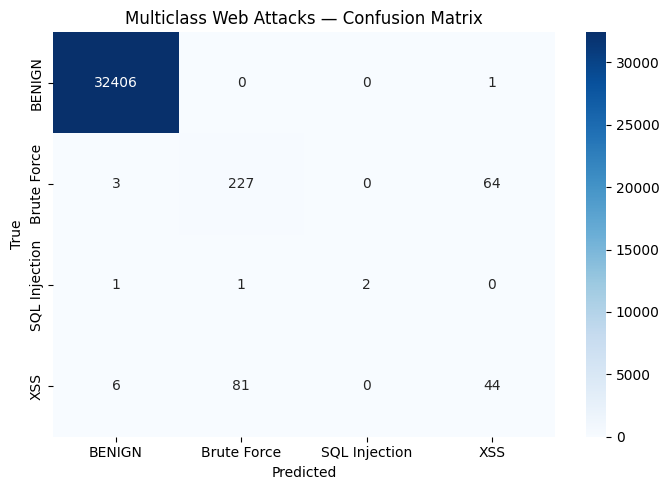

In [9]:
classes = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Multiclass Web Attacks — Confusion Matrix")
plt.tight_layout()
plt.show()